# EE 446 TinyML — Model Pruning with Quantization  
## Student TODO Version: Pruning and Quantization of a DNN Using the UCI Human Activity Recognition Dataset

### Overview
In this notebook, you will:
- train a baseline DNN on the **UCI HAR** dataset,
- apply **magnitude-based pruning**,
- compare the pruned model before and after `strip_pruning(...)`, and
- combine pruning with **float16 quantization**.

Use the **`Python (tinyml-arduino)`** Jupyter kernel for this notebook.


## 1. Environment Setup

This notebook is designed to run with the **`Python (tinyml-arduino)`** Jupyter kernel that you already created.

This notebook assumes the environment already contains:
- `tensorflow==2.14.1`
- `tensorflow-model-optimization==0.8.0`
- `numpy`, `pandas`, `matplotlib`, and `scikit-learn`

Do **not** reinstall TensorFlow packages inside the notebook if you are already using the working TinyML environment.


In [44]:
import os
import math
import zipfile
import random
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Python executable:", os.sys.executable)
print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


Python executable: /Users/meghangillen/ai/projects/tinyml-arduino/bin/python
TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 2. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals,
- **6 activity classes**, and
- predefined **training** and **test** splits.

The code below downloads and extracts the dataset if it is not already present in the working directory.


In [45]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    urllib.request.urlretrieve(dataset_url, zip_path)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset directory already exists.


## 3. Load the Data

In [46]:
def load_har_data(root_dir="UCI HAR Dataset"):
    # TODO:
    # 1. Load X_train from train/X_train.txt as float32
    # 2. Load y_train from train/y_train.txt as int32
    # 3. Load X_test from test/X_test.txt as float32
    # 4. Load y_test from test/y_test.txt as int32
    # 5. Convert labels to zero-based class indices by subtracting 1

    # <-- Enter your code here <--#
    X_train = np.loadtxt(os.path.join(root_dir, "train", "X_train.txt")).astype(np.float32)
    y_train = np.loadtxt(os.path.join(root_dir, "train", "y_train.txt")).astype(np.int32) - 1

    X_test = np.loadtxt(os.path.join(root_dir, "test", "X_test.txt")).astype(np.float32)
    y_test = np.loadtxt(os.path.join(root_dir, "test", "y_test.txt")).astype(np.int32) - 1

    return X_train, y_train, X_test, y_test
    
    #raise NotImplementedError("Complete the data-loading function.")

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

# TODO:
# Define num_features and num_classes.
# Print the train/test shapes and the number of features/classes.

# <-- Enter your code here <--#
num_features = X_train.shape[1]
num_classes = len(np.unique(y_train))

print(num_features)
print(num_classes)

561
6


## 4. Quick Inspection

In [64]:
# TODO:
# Create a small summary table showing:
# - class index,
# - class name, and
# - number of training samples in each class.

# <-- Enter your code here <--#
label_counts = pd.Series(y_train).value_counts().sort_index()
summary_df = pd.DataFrame({
    "Class Index": range(num_classes),
    "Class Name": class_names,
    "Training Samples": label_counts.values
})
summary_df

,Class Index,Class Name,Training Samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 5. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [48]:
def build_baseline_model(input_dim, num_classes):
    # TODO:
    # Build and compile a DNN with the following architecture:
    # Input -> Dense(256, relu) -> Dense(128, relu) -> Dense(64, relu) -> Dense(num_classes, softmax)
    # Use Adam with learning rate 1e-3.
    # Use sparse_categorical_crossentropy as the loss.
    # Track accuracy as a metric.

    # <-- Enter your code here <--#
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.legacy.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model
    #raise NotImplementedError("Complete the baseline DNN.")

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_32 (Dense)            (None, 256)               143872    
                                                                 
 dense_33 (Dense)            (None, 128)               32896     
                                                                 
 dense_34 (Dense)            (None, 64)                8256      
                                                                 
 dense_35 (Dense)            (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model

In [49]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

history = baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks
)

# <-- Enter your code here <--#


Epoch 1/40
92/92 [==============================] - 0s 2ms/step - loss: 0.4880 - accuracy: 0.8073 - val_loss: 0.2027 - val_accuracy: 0.9245
Epoch 2/40
92/92 [==============================] - 0s 1ms/step - loss: 0.1655 - accuracy: 0.9361 - val_loss: 0.1358 - val_accuracy: 0.9368
Epoch 3/40
92/92 [==============================] - 0s 1ms/step - loss: 0.1252 - accuracy: 0.9505 - val_loss: 0.1966 - val_accuracy: 0.9273
Epoch 4/40
92/92 [==============================] - 0s 1ms/step - loss: 0.0981 - accuracy: 0.9595 - val_loss: 0.1258 - val_accuracy: 0.9443
Epoch 5/40
92/92 [==============================] - 0s 1ms/step - loss: 0.0756 - accuracy: 0.9719 - val_loss: 0.1641 - val_accuracy: 0.9266
Epoch 6/40
92/92 [==============================] - 0s 1ms/step - loss: 0.0692 - accuracy: 0.9755 - val_loss: 0.2387 - val_accuracy: 0.9252
Epoch 7/40
92/92 [==============================] - 0s 1ms/step - loss: 0.0602 - accuracy: 0.9767 - val_loss: 0.1413 - val_accuracy: 0.9429
Epoch 8/40
92/92 [==

### Training Curves

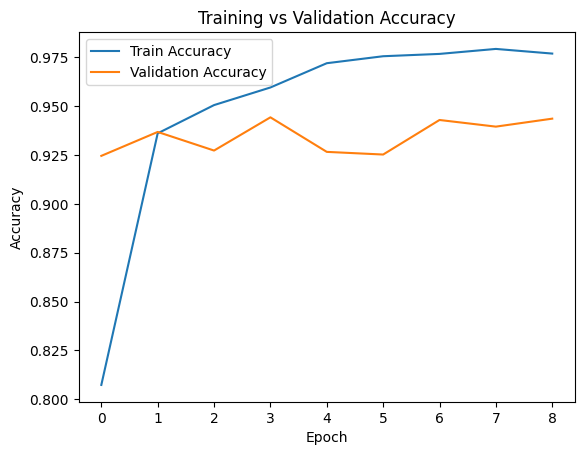

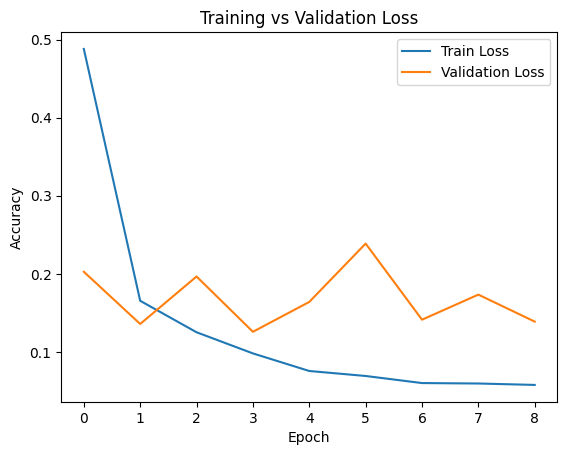

In [50]:
# TODO:
# Plot:
# 1. training accuracy vs validation accuracy
# 2. training loss vs validation loss

# <-- Enter your code here <--#
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.show()

plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()

## 6. Evaluate the Baseline Keras Model

93/93 [==============================] - 0s 506us/step
Test Accuracy: 0.9290804207668816

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.98      0.94       496
           1       0.95      0.88      0.92       471
           2       0.94      0.92      0.93       420
           3       0.93      0.87      0.90       491
           4       0.86      0.94      0.90       532
           5       1.00      0.96      0.98       537

    accuracy                           0.93      2947
   macro avg       0.93      0.93      0.93      2947
weighted avg       0.93      0.93      0.93      2947



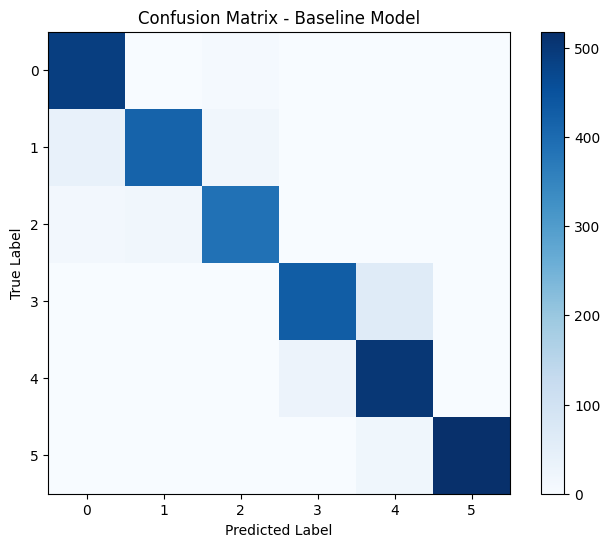

In [51]:
# TODO:
# 1. Predict class probabilities on X_test
# 2. Convert probabilities to class labels using argmax
# 3. Compute the test accuracy
# 4. Print the classification report
# 5. Plot the confusion matrix

# <-- Enter your code here <--#
y_prob = baseline_model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)

test_acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", test_acc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap="Blues")
plt.colorbar()

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Baseline Model")
plt.show()

# Part I: Model Pruning with Sparsity

In this part, we apply **magnitude-based pruning** to the DNN. The key idea is to gradually set small-magnitude weights to zero during training.

We will compare:
1. the baseline TensorFlow Lite model,
2. the pruned model converted **without** stripping the pruning wrappers, and
3. the stripped sparse model converted with **experimental sparsity-aware optimization**.


## 7. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model size.


In [52]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # TODO:
        # Quantize the input only when the TFLite input tensor expects int8 or uint8.
        # Otherwise keep the input in the required floating-point dtype.

        # <-- Enter your code here <--#
        if input_details["dtype"] == np.int8 or input_details["dtype"] == np.uint8:
            x = x / input_scale + input_zero_point
            x = np.clip(x, -128, 127).astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # TODO:
        # Dequantize the output only when the output tensor is int8 or uint8.

        # <-- Enter your code here <--#
        if output_details["dtype"] == np.int8 or output_details["dtype"] == np.uint8:
            output = (output - output_zero_point) * output_scale

        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    # TODO:
    # Create a TFLiteConverter from the Keras model and return the converted FP32 model bytes.

    # <-- Enter your code here <--#
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()

    #raise NotImplementedError("Complete the FP32 conversion helper.")


## 8. Convert the Baseline Model to TensorFlow Lite

In [53]:
# TODO:
# Convert the baseline model to FP32 TensorFlow Lite.
# Save the .tflite file, compute its size in KB, and evaluate it on X_test.

# <-- Enter your code here <--#
baseline_FP32 = convert_to_tflite_fp32(baseline_model)

baseline_FP32_file = save_binary_model(baseline_FP32, "baseline_32")

acc_32, y_pred_32 = evaluate_tflite_model(baseline_FP32, X_test, y_test)

INFO:tensorflow:Assets written to: /var/folders/ft/hk0gywbs1zq157c1btq38ptr0000gn/T/tmpcu9dk2g8/assets


INFO:tensorflow:Assets written to: /var/folders/ft/hk0gywbs1zq157c1btq38ptr0000gn/T/tmpcu9dk2g8/assets
2026-04-23 15:09:51.708461: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 15:09:51.708849: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 15:09:51.709367: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/ft/hk0gywbs1zq157c1btq38ptr0000gn/T/tmpcu9dk2g8
2026-04-23 15:09:51.709824: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 15:09:51.709828: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/ft/hk0gywbs1zq157c1btq38ptr0000gn/T/tmpcu9dk2g8
2026-04-23 15:09:51.712497: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 15:09:51.740950: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

## 9. Apply Magnitude-Based Pruning

We will prune the DNN using a **polynomial decay schedule**:
- start from low sparsity,
- gradually increase sparsity during training, and
- finish with a highly sparse model.

After training, we will compare:
- the pruned model **with** the pruning wrappers still present, and
- the final sparse model after applying `strip_pruning(...)`.


In [54]:
from tensorflow_model_optimization.sparsity.keras import (
    prune_low_magnitude,
    PolynomialDecay,
    UpdatePruningStep,
    strip_pruning
)

pruning_epochs = 12
batch_size = 64

# TODO:
# Compute steps_per_epoch using 80% of the training set and the selected batch size.
# Define pruning_params using PolynomialDecay with:
# - initial_sparsity=0.20
# - final_sparsity=0.85
# - begin_step=0
# - end_step=steps_per_epoch * pruning_epochs

# <-- Enter your code here <--#
steps_per_epoch = int(0.8 * len(X_train) / batch_size)

pruning_params = {
    "pruning_schedule": PolynomialDecay(
        initial_sparsity=0.20,
        final_sparsity=0.85,
        begin_step=0,
        end_step=steps_per_epoch * pruning_epochs
    )
}
# TODO:
# Create the pruned model by wrapping a fresh baseline DNN with prune_low_magnitude.
# Compile it with Adam(1e-3), sparse_categorical_crossentropy, and accuracy.

# <-- Enter your code here <--#
pruned_model = prune_low_magnitude(
    keras.Sequential([
        layers.Input(shape=(num_features,)),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ]),
    **pruning_params
)

pruned_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
    
pruning_callbacks = [
    UpdatePruningStep(),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Train the pruned model using:
# - validation_split=0.2
# - epochs=pruning_epochs
# - batch_size=batch_size
# - callbacks=pruning_callbacks

# <-- Enter your code here <--#
history_pruned = pruned_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=pruning_epochs,
    batch_size=batch_size,
    callbacks=pruning_callbacks
)

Epoch 1/12
92/92 [==============================] - 1s 2ms/step - loss: 0.4751 - accuracy: 0.8067 - val_loss: 0.2226 - val_accuracy: 0.9218
Epoch 2/12
92/92 [==============================] - 0s 2ms/step - loss: 0.1662 - accuracy: 0.9395 - val_loss: 0.1603 - val_accuracy: 0.9279
Epoch 3/12
92/92 [==============================] - 0s 2ms/step - loss: 0.1308 - accuracy: 0.9517 - val_loss: 0.2274 - val_accuracy: 0.9266
Epoch 4/12
92/92 [==============================] - 0s 2ms/step - loss: 0.0924 - accuracy: 0.9685 - val_loss: 0.1644 - val_accuracy: 0.9334
Epoch 5/12
92/92 [==============================] - 0s 2ms/step - loss: 0.1505 - accuracy: 0.9452 - val_loss: 0.1418 - val_accuracy: 0.9381
Epoch 6/12
92/92 [==============================] - 0s 2ms/step - loss: 0.1465 - accuracy: 0.9503 - val_loss: 0.1410 - val_accuracy: 0.9334
Epoch 7/12
92/92 [==============================] - 0s 2ms/step - loss: 0.3562 - accuracy: 0.9252 - val_loss: 0.1651 - val_accuracy: 0.9354
Epoch 8/12
92/92 [==

## 10. Convert the Pruned Model Before and After Stripping the Pruning Wrappers

First, we convert the pruned model **with** the pruning wrappers still attached.

Next, we strip the pruning wrappers and convert the resulting sparse model with:
- `tf.lite.Optimize.EXPERIMENTAL_SPARSITY`

This is the proper way to preserve sparsity in the exported TensorFlow Lite model.


In [55]:
# TODO:
# 1. Convert the pruned model WITH the pruning wrappers still attached to FP32 TensorFlow Lite.
# 2. Save the model and evaluate it on X_test.
# 3. Strip the pruning wrappers using strip_pruning(...).
# 4. Convert the stripped model with tf.lite.Optimize.EXPERIMENTAL_SPARSITY.
# 5. Save the stripped sparse model and evaluate it on X_test.

# <-- Enter your code here <--#
wrapped_32 = convert_to_tflite_fp32(pruned_model)
wrapped_FP32_file = save_binary_model(wrapped_32, "wrapped_32")
acc_wrapped, y_pred_wrapped = evaluate_tflite_model(wrapped_32, X_test, y_test)

stripped_model = strip_pruning(pruned_model)
converter = tf.lite.TFLiteConverter.from_keras_model(stripped_model)
converter.optimizations = [tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
stripped_32 = converter.convert()
stripped_32_file = save_binary_model(stripped_32, "stripped_32")
acc_stripped, y_pred_stripped = evaluate_tflite_model(stripped_32, X_test, y_test)

INFO:tensorflow:Assets written to: /var/folders/ft/hk0gywbs1zq157c1btq38ptr0000gn/T/tmpgosnwcls/assets


INFO:tensorflow:Assets written to: /var/folders/ft/hk0gywbs1zq157c1btq38ptr0000gn/T/tmpgosnwcls/assets
2026-04-23 15:10:00.179225: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 15:10:00.179237: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 15:10:00.179337: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/ft/hk0gywbs1zq157c1btq38ptr0000gn/T/tmpgosnwcls
2026-04-23 15:10:00.180900: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 15:10:00.180905: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/ft/hk0gywbs1zq157c1btq38ptr0000gn/T/tmpgosnwcls
2026-04-23 15:10:00.185127: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 15:10:00.221260: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

INFO:tensorflow:Assets written to: /var/folders/ft/hk0gywbs1zq157c1btq38ptr0000gn/T/tmpyn2wmo7_/assets


INFO:tensorflow:Assets written to: /var/folders/ft/hk0gywbs1zq157c1btq38ptr0000gn/T/tmpyn2wmo7_/assets
2026-04-23 15:10:00.792956: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 15:10:00.792967: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 15:10:00.793054: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/ft/hk0gywbs1zq157c1btq38ptr0000gn/T/tmpyn2wmo7_
2026-04-23 15:10:00.793364: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 15:10:00.793368: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/ft/hk0gywbs1zq157c1btq38ptr0000gn/T/tmpyn2wmo7_
2026-04-23 15:10:00.794122: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 15:10:00.803223: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

## 11. Part I Comparison: Accuracy and Model Size

In [57]:
# TODO:
# Create a comparison DataFrame for Part I with the columns:
# Model, Format, Test Accuracy, Model Size (KB)

# Include:
# - baseline FP32 TFLite
# - pruned FP32 TFLite with mask
# - stripped sparse FP32 TFLite

# <-- Enter your code here <--#

model_comparison = pd.DataFrame({
    "Model": ["Baseline FP32", "Pruned FP32", "Stripped Sparse FP32"],
    "Format": ["FP32", "FP32", "FP32"],
    "Test Accuracy": [acc_32, acc_wrapped, acc_stripped],
    "Model Size": [baseline_FP32_file, wrapped_FP32_file, stripped_32_file]
})
model_comparison

,Model,Format,Test Accuracy,Model Size
0,Baseline FP32,FP32,0.929080,726.796875
1,Pruned FP32,FP32,0.906006,1454.257812
2,Stripped Sparse FP32,FP32,0.906006,194.417969


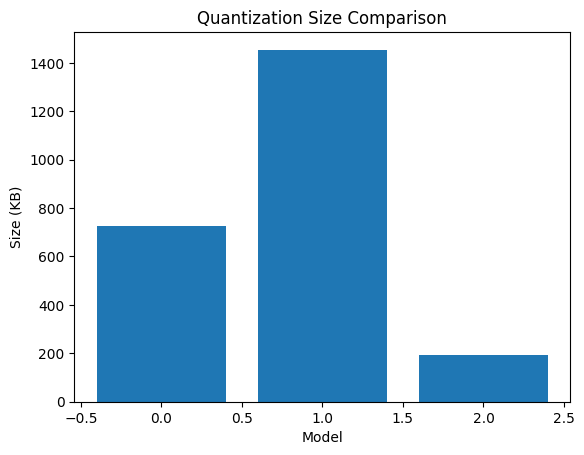

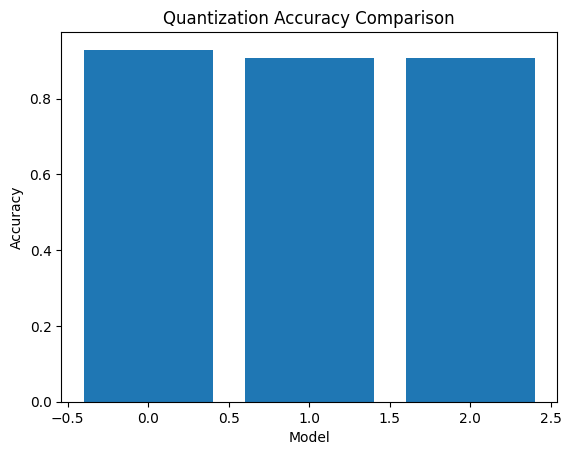

In [58]:
# TODO:
# Plot:
# 1. a bar chart of the Part I model sizes
# 2. a bar chart of the Part I test accuracies

# <-- Enter your code here <--#
x = range(3)
size = [baseline_FP32_file, wrapped_FP32_file, stripped_32_file]
plt.figure()
plt.bar(x, size)
plt.xlabel("Model")
plt.ylabel("Size (KB)")
plt.title("Quantization Size Comparison")
plt.show()

accuracies = [acc_32, acc_wrapped, acc_stripped]
plt.figure()
plt.bar(x, accuracies)
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Quantization Accuracy Comparison")
plt.show()


### Confusion Matrix for the Stripped Sparse Model


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       496
           1       0.93      0.94      0.94       471
           2       0.91      0.92      0.92       420
           3       0.96      0.64      0.77       491
           4       0.74      0.97      0.84       532
           5       1.00      0.98      0.99       537

    accuracy                           0.91      2947
   macro avg       0.92      0.90      0.90      2947
weighted avg       0.92      0.91      0.90      2947



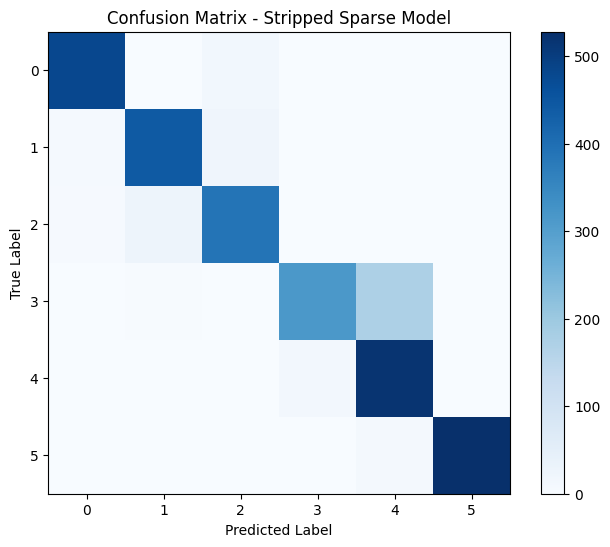

In [59]:
# TODO:
# Plot the confusion matrix for the stripped sparse TFLite model.
# Print the classification report for the stripped sparse TFLite model.

# <-- Enter your code here <--#

print("\nClassification Report:")
print(classification_report(y_test, y_pred_stripped))

cm = confusion_matrix(y_test, y_pred_stripped)

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap="Blues")
plt.colorbar()

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Stripped Sparse Model")
plt.show()

# Part II: Model Pruning + Float16 Quantization

In this part, we combine **pruning** and **float16 quantization**.

We will compare:
1. the pruned TensorFlow Lite model **with** the pruning wrappers still attached, after float16 quantization, and
2. the stripped sparse TensorFlow Lite model after **both** sparsity-aware optimization and float16 quantization.

This lets us observe whether properly finalizing the pruned model leads to a more compact deployable representation.


In [60]:
# TODO:
# Part II: combine pruning and float16 quantization.
#
# 1. Convert the pruned model with mask using:
#    - optimizations = [tf.lite.Optimize.DEFAULT]
#    - supported_types = [tf.float16]
# 2. Save and evaluate the float16 model with mask.
# 3. Convert the stripped sparse model using:
#    - optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
#    - supported_types = [tf.float16]
# 4. Save and evaluate the stripped sparse + float16 model.

# <-- Enter your code here <--#
#FP16 - Pruned Model w/ Mask
converter = tf.lite.TFLiteConverter.from_keras_model(pruned_model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]

pruned_fp16 = converter.convert()

pruned_fp16_file = save_binary_model(pruned_fp16, "pruned_fp16")
acc_pruned_fp16, y_pred_pruned_fp16 = evaluate_tflite_model(pruned_fp16, X_test, y_test)

#FP16 - Stripped Model 
stripped_model = strip_pruning(pruned_model)

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_model)

converter.optimizations = [
    tf.lite.Optimize.DEFAULT,
    tf.lite.Optimize.EXPERIMENTAL_SPARSITY
]

converter.target_spec.supported_types = [tf.float16]

stripped_fp16 = converter.convert()

stripped_fp16_file = save_binary_model(stripped_fp16, "stripped_fp16")

acc_stripped_fp16, y_pred_stripped_fp16 = evaluate_tflite_model(stripped_fp16, X_test, y_test)

INFO:tensorflow:Assets written to: /var/folders/ft/hk0gywbs1zq157c1btq38ptr0000gn/T/tmp3bgbk8xe/assets


INFO:tensorflow:Assets written to: /var/folders/ft/hk0gywbs1zq157c1btq38ptr0000gn/T/tmp3bgbk8xe/assets
2026-04-23 15:10:13.595165: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 15:10:13.595181: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 15:10:13.595310: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/ft/hk0gywbs1zq157c1btq38ptr0000gn/T/tmp3bgbk8xe
2026-04-23 15:10:13.596830: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 15:10:13.596835: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/ft/hk0gywbs1zq157c1btq38ptr0000gn/T/tmp3bgbk8xe
2026-04-23 15:10:13.603117: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 15:10:13.639766: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

INFO:tensorflow:Assets written to: /var/folders/ft/hk0gywbs1zq157c1btq38ptr0000gn/T/tmpt6juwtob/assets


INFO:tensorflow:Assets written to: /var/folders/ft/hk0gywbs1zq157c1btq38ptr0000gn/T/tmpt6juwtob/assets
2026-04-23 15:10:14.225196: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 15:10:14.225209: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 15:10:14.225304: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/ft/hk0gywbs1zq157c1btq38ptr0000gn/T/tmpt6juwtob
2026-04-23 15:10:14.225681: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 15:10:14.225685: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/ft/hk0gywbs1zq157c1btq38ptr0000gn/T/tmpt6juwtob
2026-04-23 15:10:14.226508: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 15:10:14.235871: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

## 12. Part II Comparison: Accuracy and Model Size

In [61]:
# TODO:
# Create a Part II comparison DataFrame with the columns:
# Model, Format, Test Accuracy, Model Size (KB)
#
# Include:
# - pruned FP32 with mask
# - stripped sparse FP32
# - pruned float16 with mask
# - stripped sparse float16

# <-- Enter your code here <--#
part2_model_comparison = pd.DataFrame({
    "Model": ["Pruned FP32", "Stripped Sparse FP32", "Pruned FP16", "Stripped Sparse FP16"],
    "Format": ["FP32", "FP32", "FP16", "FP16"],
    "Test Accuracy": [acc_wrapped, acc_stripped, acc_pruned_fp16, acc_stripped_fp16],
    "Model Size": [wrapped_FP32_file, stripped_32_file, pruned_fp16_file, stripped_fp16_file]
})
part2_model_comparison

,Model,Format,Test Accuracy,Model Size
0,Pruned FP32,FP32,0.906006,1454.257812
1,Stripped Sparse FP32,FP32,0.906006,194.417969
2,Pruned FP16,FP16,0.905667,732.667969
3,Stripped Sparse FP16,FP16,0.905667,129.285156


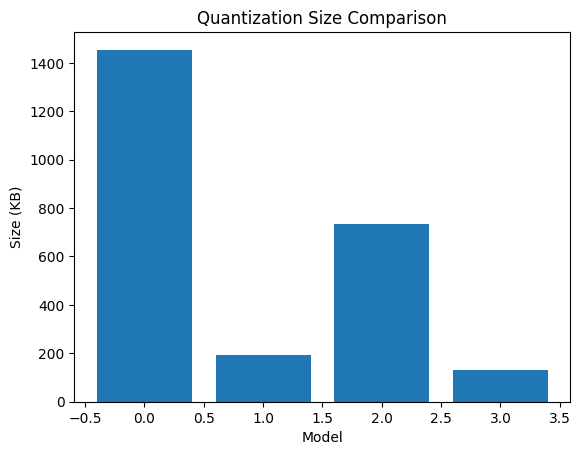

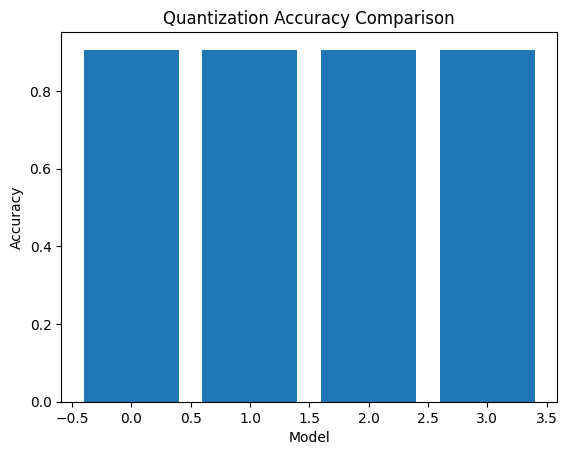

In [62]:
# TODO:
# Plot:
# 1. a bar chart of Part II model sizes
# 2. a bar chart of Part II test accuracies

# <-- Enter your code here <--#
x = range(4)
size = [wrapped_FP32_file, stripped_32_file, pruned_fp16_file, stripped_fp16_file]
plt.figure()
plt.bar(x, size)
plt.xlabel("Model")
plt.ylabel("Size (KB)")
plt.title("Quantization Size Comparison")
plt.show()

accuracies = [acc_wrapped, acc_stripped, acc_pruned_fp16, acc_stripped_fp16]
plt.figure()
plt.bar(x, accuracies)
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Quantization Accuracy Comparison")
plt.show()

### Confusion Matrix for the Stripped Sparse + Float16 Model

Stripped Sparse FP16 Model

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       496
           1       0.93      0.94      0.94       471
           2       0.91      0.92      0.92       420
           3       0.96      0.64      0.77       491
           4       0.74      0.97      0.84       532
           5       1.00      0.98      0.99       537

    accuracy                           0.91      2947
   macro avg       0.92      0.90      0.90      2947
weighted avg       0.92      0.91      0.90      2947



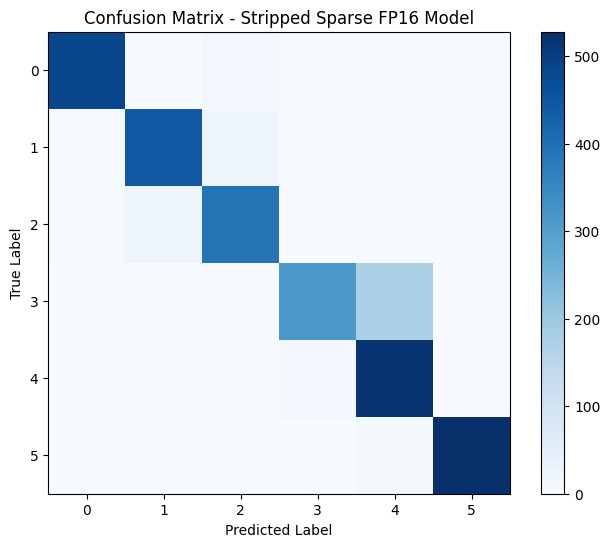

In [63]:
# TODO:
# Plot the confusion matrix for the stripped sparse + float16 TFLite model.
# Print the classification report for the stripped sparse + float16 TFLite model.

# <-- Enter your code here <--#

print("Stripped Sparse FP16 Model")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_stripped_fp16))

cm = confusion_matrix(y_test, y_pred_stripped_fp16)

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap="Blues")
plt.colorbar()

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Stripped Sparse FP16 Model")
plt.show()


## 13. Summary Questions

Write short answers to the following:
1. Did pruning alone reduce the TensorFlow Lite file size when the pruning wrappers were still attached?
2. Why does `strip_pruning(...)` matter before export?
3. Which model had the smallest file size in this notebook?
4. Did float16 quantization noticeably change the test accuracy?
5. If you were deploying this model on a resource-constrained device, which version would you choose and why?

### Answers

1. The pruning does not reduce the file size when the pruning wrappers are still attached. They actually made the file larger.
2. The strip pruning matters because it removes the wrappers and each layer is collapsed back to Keras Dense layers. 
3. The stripped FP16 model was the smallest size. The stripped FP32 was the second smallest.
4. The testing accuracy was really similar for all of them. Up to two decimal points they were the same.
5. I would choose the smallest model as the sparse FP16 model. Since all models retained high accuracy, I would choose the smallest one for deployment. 


## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- output cells or screenshots showing the comparison tables,
- confusion matrices for the baseline model and your final highlighted compressed model,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors using the **`Python (tinyml-arduino)`** kernel.
